In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df =pd.read_csv(r"C:\Users\merve\Desktop\Calismalar\Credit-Cart-Unsupervised\CC GENERAL.csv")

In [4]:
df

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.40,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.00,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.00,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.00,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.00,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8945,C19186,28.493517,1.000000,291.12,0.00,291.12,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,325.594462,48.886365,0.500000,6
8946,C19187,19.183215,1.000000,300.00,0.00,300.00,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,275.861322,NaN,0.000000,6
8947,C19188,23.398673,0.833333,144.40,0.00,144.40,0.000000,0.833333,0.000000,0.666667,0.000000,0,5,1000.0,81.270775,82.418369,0.250000,6
8948,C19189,13.457564,0.833333,0.00,0.00,0.00,36.558778,0.000000,0.000000,0.000000,0.166667,2,0,500.0,52.549959,55.755628,0.250000,6


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   str    
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHASES_TRX    

In [6]:
#Balance : hesapta kalan bakiye
#Balance_frequency : bakiyenin güncelleme sıklığı , 1= sık güncellenir 0=nadir günceellenir
#purchases : hesaptan yapılan toplam alışveriş tutarı
# ONEOFF_PURCHASES: tek seferde yapılan alışveriş tutarı
# INSTALLMENTS_PURCHASES : taksitli yapılan alışveriş tutarı
#CASH_ADVANCE : çekilen nakit avans tutarı
#PURCHASES_FREQUENCY : alışveriş yapma sıklığı
#ONEOFF_PURCHASES_FREQUENCY : peşin alışverişlerin sıklığı
#PURCHASES_INSTALLMENTS_FREQUENCY : taksitli alışverişlerin sıklığı
#CASH_ADVANCE_FREQUENCY : nakit avans çekme sıklığı
# CASH_ADVANCE_TRX : nakit avans işlem sayısı
# PURCHASES_TRX :alışveriş işlem sayısı
#CREDIT_LIMIT : kredi kartı limiti 
#PAYMENTS : karta yatırılan toplam ödeme
# MINIMUM_PAYMENT : asgari ödeme tutarı
# SPRC_FULL_PAYMENT : asgari değil hepsini ödeme yüzdesi
#TENURE : kredi kartı hizmetini kullanma süresi (ay)

In [7]:
df.describe()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000,8637.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.449450,1733.143852,864.206542,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.815725,2895.063757,2372.446607,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,169.123707,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,825.485459,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


In [8]:
import math

def plot_all_histograms(df, title_prefix=""):
    num_cols = df.select_dtypes(include=[np.number]).columns
    n_cols = 3
    n_rows = math.ceil(len(num_cols) / n_cols)

    plt.figure(figsize=(5 * n_cols, 4 * n_rows))

    for i, col in enumerate(num_cols, 1):
        plt.subplot(n_rows, n_cols, i)
        sns.histplot(df[col], kde=True, bins=30)
        plt.title(f"{title_prefix}{col}")
        plt.xlabel("")
        plt.ylabel("")

    plt.tight_layout()
    plt.show()

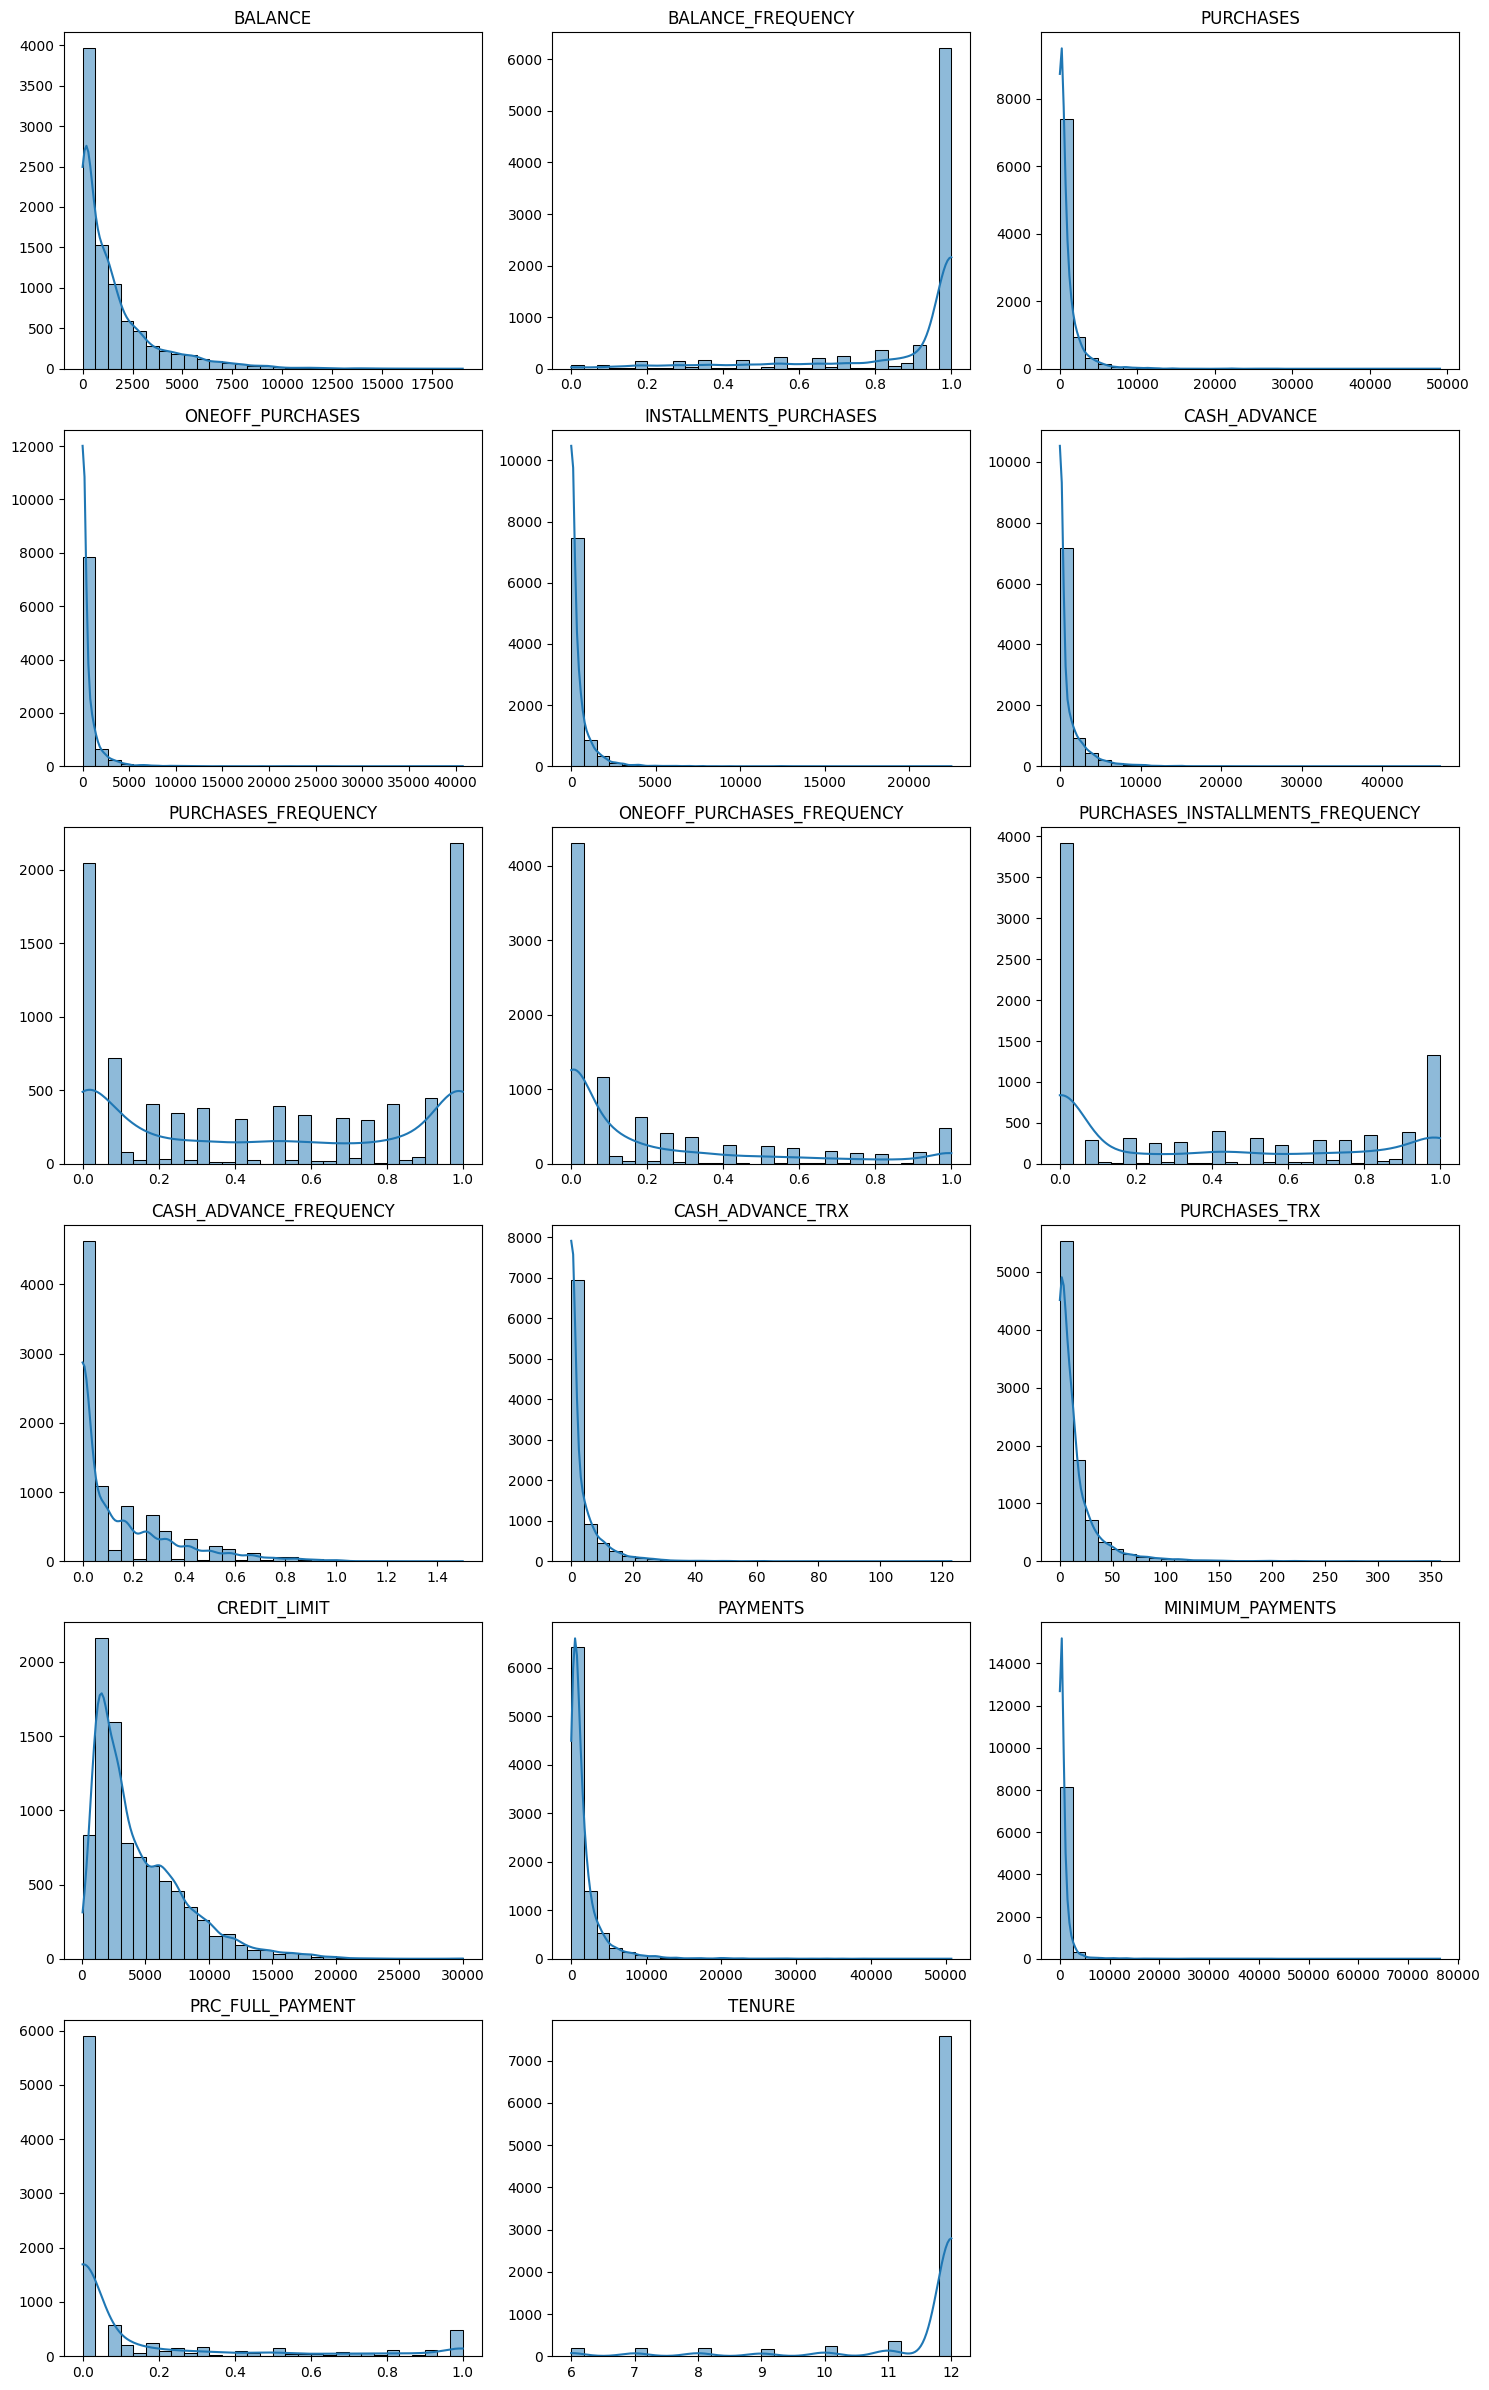

In [9]:
plot_all_histograms(df)

In [10]:
df = df.drop('CUST_ID',axis=1)

In [11]:
df.isnull().sum()

BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64

In [12]:
df['MINIMUM_PAYMENTS'].fillna(df['MINIMUM_PAYMENTS'].median(),inplace=True)
df['CREDIT_LIMIT'].fillna(df['CREDIT_LIMIT'].median(),inplace=True)

C:\Users\merve\AppData\Local\Temp\ipykernel_8396\479818256.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['MINIMUM_PAYMENTS'].fillna(df['MINIMUM_PAYMENTS'].median(),inplace=True)
C:\Users\merve\AppData\Local\Temp\ipykernel_8396\479818256.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series thr

0       1000.0
1       7000.0
2       7500.0
3       7500.0
4       1200.0
         ...  
8945    1000.0
8946    1000.0
8947    1000.0
8948     500.0
8949    1200.0
Name: CREDIT_LIMIT, Length: 8950, dtype: float64

In [13]:
df.isnull().sum()

BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64

In [14]:
df = df.fillna(df.median())

In [15]:
df.isnull().sum()

BALANCE                             0
BALANCE_FREQUENCY                   0
PURCHASES                           0
ONEOFF_PURCHASES                    0
INSTALLMENTS_PURCHASES              0
CASH_ADVANCE                        0
PURCHASES_FREQUENCY                 0
ONEOFF_PURCHASES_FREQUENCY          0
PURCHASES_INSTALLMENTS_FREQUENCY    0
CASH_ADVANCE_FREQUENCY              0
CASH_ADVANCE_TRX                    0
PURCHASES_TRX                       0
CREDIT_LIMIT                        0
PAYMENTS                            0
MINIMUM_PAYMENTS                    0
PRC_FULL_PAYMENT                    0
TENURE                              0
dtype: int64

In [16]:
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()

df_scaled = ss.fit_transform(df)
df

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,40.900749,0.818182,95.40,0.00,95.40,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,3202.467416,0.909091,0.00,0.00,0.00,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,2495.148862,1.000000,773.17,773.17,0.00,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,1666.670542,0.636364,1499.00,1499.00,0.00,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,312.343947,0.000000,12
4,817.714335,1.000000,16.00,16.00,0.00,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8945,28.493517,1.000000,291.12,0.00,291.12,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,325.594462,48.886365,0.500000,6
8946,19.183215,1.000000,300.00,0.00,300.00,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,275.861322,312.343947,0.000000,6
8947,23.398673,0.833333,144.40,0.00,144.40,0.000000,0.833333,0.000000,0.666667,0.000000,0,5,1000.0,81.270775,82.418369,0.250000,6
8948,13.457564,0.833333,0.00,0.00,0.00,36.558778,0.000000,0.000000,0.000000,0.166667,2,0,500.0,52.549959,55.755628,0.250000,6


In [17]:
df.columns

Index(['BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES', 'ONEOFF_PURCHASES',
       'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'PURCHASES_FREQUENCY',
       'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY',
       'CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX',
       'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT',
       'TENURE'],
      dtype='str')

In [18]:
df_scaled = pd.DataFrame(df_scaled,columns=df.columns)

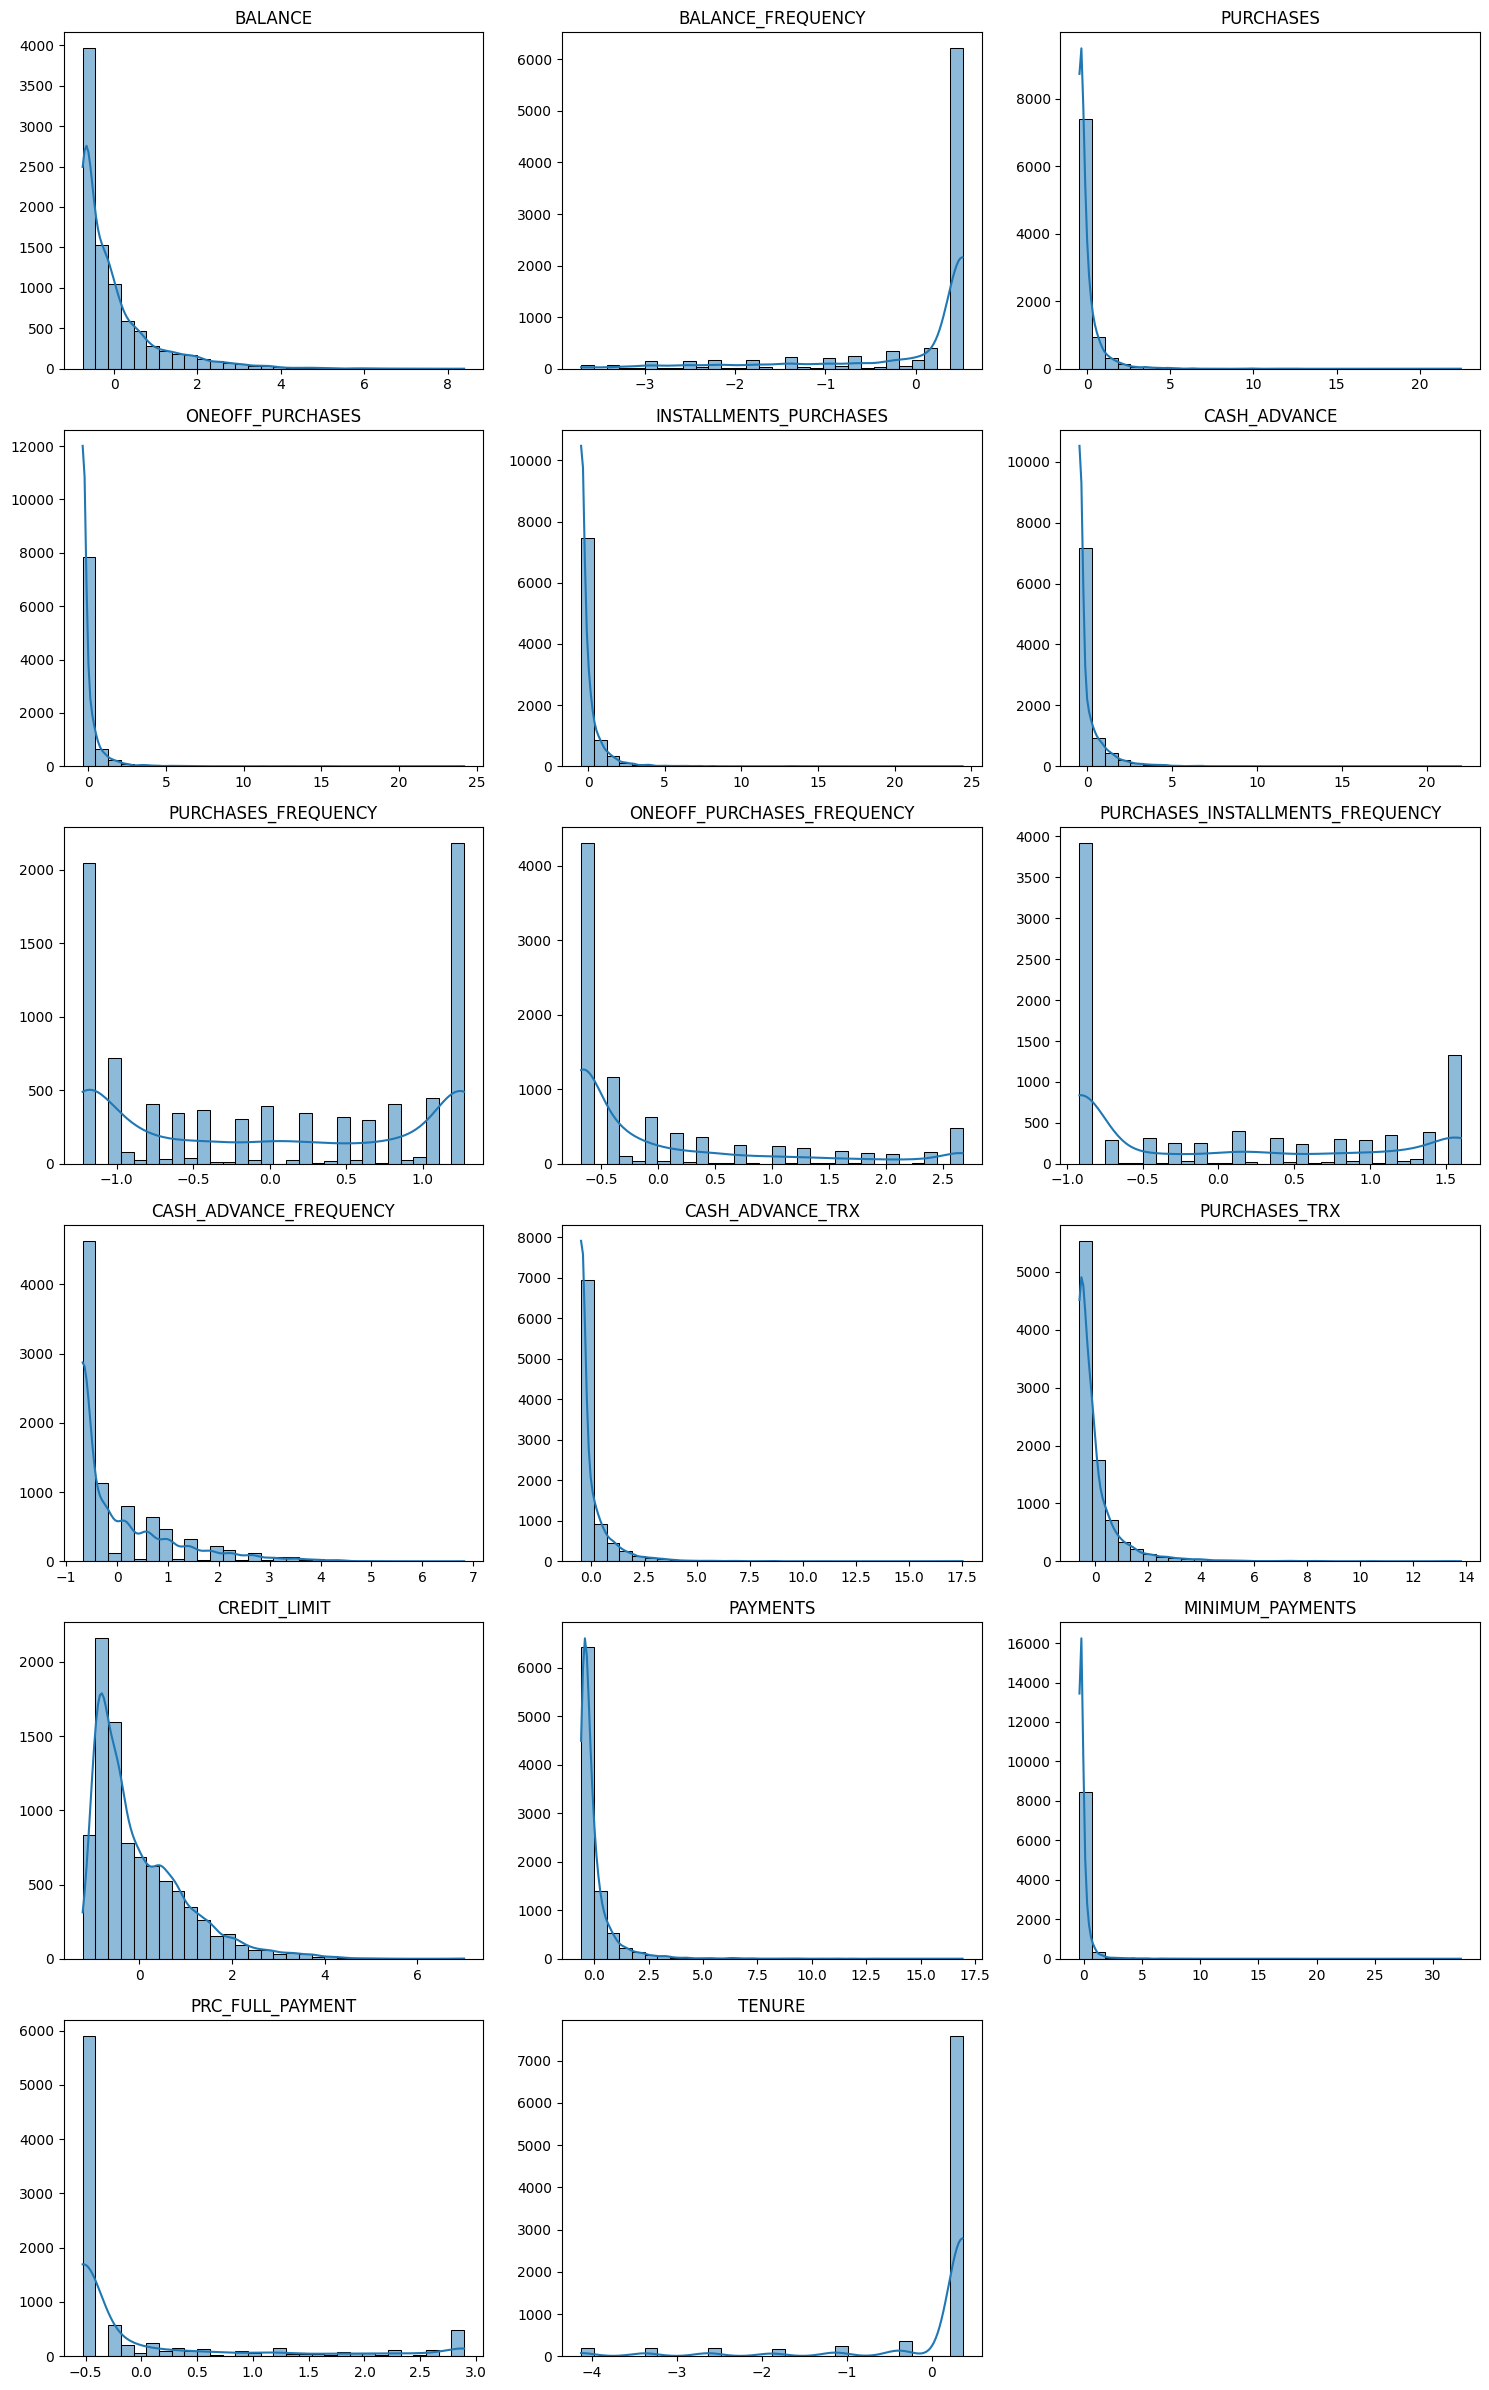

In [19]:
plot_all_histograms(df_scaled)

In [20]:
from sklearn.preprocessing import StandardScaler,MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
import scipy.cluster.hierarchy as sch
from sklearn.cluster import DBSCAN, HDBSCAN

pca =PCA()
pca_df_scaled = pca.fit_transform(df_scaled)

In [21]:
pca_df_scaled

array([[-1.68364879e+00, -1.07224148e+00, -4.75660084e-01, ...,
        -1.49962336e-01,  4.82655442e-02,  1.60528758e-04],
       [-1.13408493e+00,  2.50914981e+00, -6.02216308e-01, ...,
         5.32950936e-01, -8.29086834e-02, -3.07157686e-06],
       [ 9.69394988e-01, -3.83576903e-01, -9.09697616e-02, ...,
        -2.21683158e-01,  5.11324941e-01, -2.23296494e-05],
       ...,
       [-9.28985122e-01, -1.80804835e+00,  4.58242377e-01, ...,
        -4.60675887e-01,  1.57799814e-01,  1.63043472e-04],
       [-2.33784475e+00, -6.53611332e-01, -9.82831153e-01, ...,
        -2.63789927e-01, -1.89595873e-01,  8.58602334e-05],
       [-5.58026533e-01, -4.00646098e-01, -1.03364560e+00, ...,
         4.18806582e-01,  3.57426555e-01,  7.42947186e-05]],
      shape=(8950, 17))

In [22]:
pca_df_scaled = pd.DataFrame(pca_df_scaled)

In [23]:
pca_df_scaled

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
0,-1.683649,-1.072241,-0.475660,0.679928,-0.043195,-0.068069,-0.822155,-0.018952,0.118336,0.078196,-0.235948,0.052497,0.081637,0.187992,-0.149962,0.048266,0.000161
1,-1.134085,2.509150,-0.602216,-0.109542,-0.662638,1.102255,0.384282,0.176154,0.674472,0.777929,-0.870746,0.607171,0.034550,0.733098,0.532951,-0.082909,-0.000003
2,0.969395,-0.383577,-0.090970,1.238359,2.166584,0.320185,1.542496,-0.229364,-0.867803,0.001744,-0.762170,-0.683870,-0.696544,-0.042389,-0.221683,0.511325,-0.000022
3,-0.888220,0.004648,-1.499800,1.075271,-0.225828,0.171540,0.236644,-0.690410,-0.064245,-0.393690,0.747670,-0.119186,0.127887,0.417356,0.091930,-0.016174,0.000010
4,-1.600021,-0.683795,-0.347927,1.013642,0.453816,-0.077004,-0.698278,0.245311,0.578032,0.122073,-0.455167,0.108719,0.037507,0.040989,-0.290908,-0.070603,0.000081
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8945,-0.362572,-2.013437,0.975609,-2.742418,-0.124714,-2.673427,1.561393,0.277404,1.371131,0.845167,0.194939,-0.020982,0.078284,-0.120858,-0.466458,0.157827,0.000173
8946,-0.580810,-1.675663,1.222354,-1.980537,0.073504,-3.312539,1.068590,-0.639929,0.940227,1.245566,0.069507,-0.458772,0.287664,-0.084968,-0.437730,0.190459,0.000196
8947,-0.928985,-1.808048,0.458242,-2.296301,-0.234615,-2.980784,1.403265,-0.292832,0.810029,0.830136,0.120176,-0.073141,0.138482,-0.099435,-0.460676,0.157800,0.000163
8948,-2.337845,-0.653611,-0.982831,-1.847692,0.070276,-3.179484,0.973534,0.230863,1.205675,-0.268663,-0.306599,0.113269,0.349854,-0.250321,-0.263790,-0.189596,0.000086


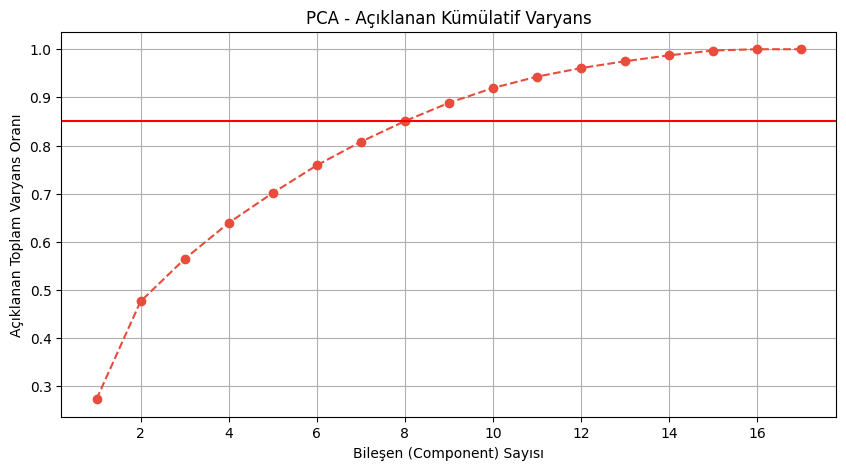

In [24]:
kumulatif_varyans = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(kumulatif_varyans) + 1), kumulatif_varyans, marker='o', linestyle='--', color='#e74c3c')
plt.title('PCA - Açıklanan Kümülatif Varyans')
plt.xlabel('Bileşen (Component) Sayısı')
plt.ylabel('Açıklanan Toplam Varyans Oranı')
plt.axhline(y=0.85, color='r', linestyle='-') 
plt.grid(True)
plt.show()

In [25]:
pca2 = PCA(n_components=8)
pca2_scaled = pca2.fit_transform(df_scaled)

pca_df = pd.DataFrame(
    pca2_scaled, 
    columns=[f'PC{i}' for i in range(1, 9)]
)

print(f"Yeni veri setinin boyutu: {pca_df.shape}")
pca_df.head()

Yeni veri setinin boyutu: (8950, 8)


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8
0,-1.683649,-1.072241,-0.475660,0.679928,-0.043195,-0.068069,-0.822155,-0.018952
1,-1.134085,2.509150,-0.602216,-0.109542,-0.662638,1.102255,0.384282,0.176154
2,0.969395,-0.383577,-0.090970,1.238359,2.166584,0.320185,1.542496,-0.229364
3,-0.888220,0.004648,-1.499800,1.075271,-0.225828,0.171540,0.236644,-0.690410
4,-1.600021,-0.683795,-0.347927,1.013642,0.453816,-0.077004,-0.698278,0.245311


In [26]:
inertia= []
k_araligi = range(1, 15)

for k in k_araligi:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(pca_df)
    inertia.append(kmeans.inertia_)

In [27]:
inertia

[129405.96611955868,
 105180.76649540866,
 89942.77846981045,
 83463.63410298813,
 70703.42878758049,
 64084.417203244695,
 61141.56059063254,
 55750.90831718247,
 53061.62889783927,
 48181.43282060603,
 46320.2705430766,
 43421.637951515964,
 41645.99474510718,
 40582.94638905928]

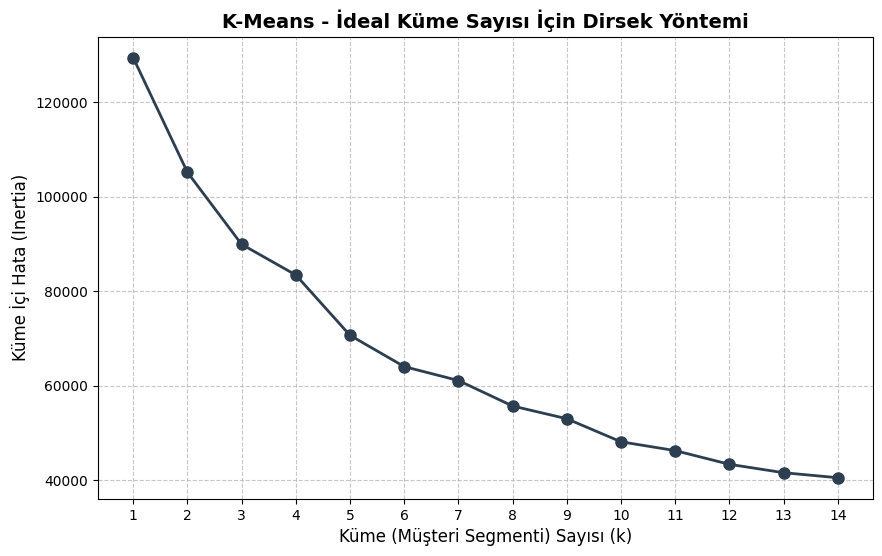

In [28]:
plt.figure(figsize=(10, 6))
plt.plot(k_araligi, inertia, marker='o', linestyle='-', color='#2c3e50', linewidth=2, markersize=8)
plt.title('K-Means - İdeal Küme Sayısı İçin Dirsek Yöntemi', fontsize=14, fontweight='bold')
plt.xlabel('Küme (Müşteri Segmenti) Sayısı (k)', fontsize=12)
plt.ylabel('Küme İçi Hata (Inertia)', fontsize=12)
plt.xticks(k_araligi)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [29]:
labels = kmeans.fit(pca_df).labels_

In [30]:
labels

array([12,  1,  8, ..., 13, 13, 13], shape=(8950,), dtype=int32)

In [31]:
from sklearn.metrics import silhouette_score
silhouette_score(pca_df,labels)

0.22825491141426535

In [37]:
kmeans_final = KMeans(n_clusters=4, random_state=42, n_init='auto')
km_pred = kmeans_final.fit_predict(pca_df)

df['Musteri_Segmenti'] = km_pred

col = ['BALANCE', 'PURCHASES', 'CASH_ADVANCE', 'CREDIT_LIMIT']
profil_ozeti = df.groupby('Musteri_Segmenti')[col].mean().round(2)

print(profil_ozeti)

                  BALANCE  PURCHASES  CASH_ADVANCE  CREDIT_LIMIT
Musteri_Segmenti                                                
0                 4775.46     597.17       4713.75       7816.01
1                 1013.50     308.71        515.22       3374.72
2                 1341.16    2297.91        240.75       5358.63
3                  762.44     406.20        969.97       2400.78


In [38]:
pca_df

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8
0,-1.683649,-1.072241,-0.475660,0.679928,-0.043195,-0.068069,-0.822155,-0.018952
1,-1.134085,2.509150,-0.602216,-0.109542,-0.662638,1.102255,0.384282,0.176154
2,0.969395,-0.383577,-0.090970,1.238359,2.166584,0.320185,1.542496,-0.229364
3,-0.888220,0.004648,-1.499800,1.075271,-0.225828,0.171540,0.236644,-0.690410
4,-1.600021,-0.683795,-0.347927,1.013642,0.453816,-0.077004,-0.698278,0.245311
...,...,...,...,...,...,...,...,...
8945,-0.362572,-2.013437,0.975609,-2.742418,-0.124714,-2.673427,1.561393,0.277404
8946,-0.580810,-1.675663,1.222354,-1.980537,0.073504,-3.312539,1.068590,-0.639929
8947,-0.928985,-1.808048,0.458242,-2.296301,-0.234615,-2.980784,1.403265,-0.292832
8948,-2.337845,-0.653611,-0.982831,-1.847692,0.070276,-3.179484,0.973534,0.230863


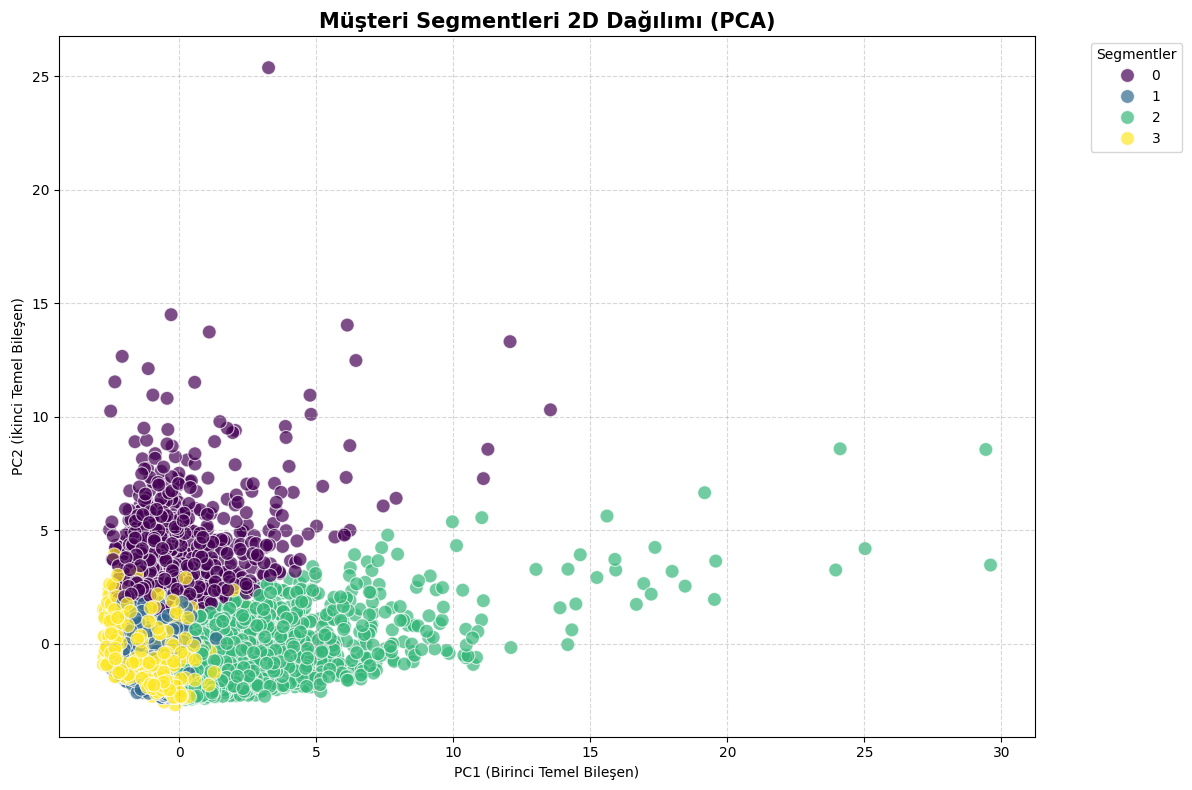

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

sns.scatterplot(
    x=pca_df['PC1'], 
    y=pca_df['PC2'], 
    hue=df['Musteri_Segmenti'], 
    palette='viridis', 
    s=100, 
    alpha=0.7
)

plt.title('Müşteri Segmentleri 2D Dağılımı (PCA)', fontsize=15, fontweight='bold')
plt.xlabel('PC1 (Birinci Temel Bileşen)')
plt.ylabel('PC2 (İkinci Temel Bileşen)')
plt.legend(title='Segmentler', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [40]:
df['Musteri_Segmenti'] = kmeans.labels_

col = [
    'BALANCE',                 
    'PURCHASES',              
    'ONEOFF_PURCHASES',       
    'INSTALLMENTS_PURCHASES',  
    'CASH_ADVANCE',     
    'CREDIT_LIMIT'      
]

profil_ozeti = df.groupby('Musteri_Segmenti')[col].mean().round(2)
profil_ozeti.style.background_gradient(cmap='Blues')

,BALANCE,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,CREDIT_LIMIT
Musteri_Segmenti,,,,,,
0,6519.280000,681.490000,398.560000,283.080000,3586.270000,10357.410000
1,2369.630000,175.720000,129.360000,46.400000,2553.990000,4275.080000
2,2479.650000,4080.900000,2577.570000,1504.450000,457.600000,7805.190000
3,94.500000,924.860000,138.730000,786.260000,24.230000,3850.150000
4,5212.550000,822.060000,512.950000,309.120000,8878.960000,8790.850000
5,118.430000,313.530000,193.210000,120.600000,334.910000,4039.140000
6,4268.590000,893.450000,142.230000,751.220000,957.140000,4517.570000
7,5601.640000,28394.160000,22858.460000,5535.710000,1014.210000,15886.360000
8,989.540000,1696.500000,1483.400000,213.160000,177.430000,5859.060000


In [41]:
#7 gibi Purchases kolonu yüksek , credit_limit kolonu yüksek olanlar 'EN ZENGİN'
#4 gibi Cash_advance kolonu , Balance kolonu yğksek olanlar 'NAKİT SIKINTISI OLAN'
#10 gibi installments_purchases kolonu yüksek olanlar 'TAKSİTLİ ALIŞVERİŞ YAPAN'
#13. satır 'PASİF'

In [ ]:
segment_isimleri = {
    7: 'VIP / Premium Müşteri',
    4: 'Riskli / Nakit Avansçı',
    10: 'Taksitli Alışverişçi',
    13: 'Pasif / Uyuyan Müşteri'
}

df['Musteri_Profili'] = df['Musteri_Segmenti'].map(segment_isimleri).fillna('Standart Müşteri')

In [44]:
df

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,Musteri_Segmenti,Musteri_Profili
0,40.900749,0.818182,95.40,0.00,95.40,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12,12,Standart Müşteri
1,3202.467416,0.909091,0.00,0.00,0.00,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12,1,Standart Müşteri
2,2495.148862,1.000000,773.17,773.17,0.00,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12,8,Standart Müşteri
3,1666.670542,0.636364,1499.00,1499.00,0.00,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,312.343947,0.000000,12,12,Standart Müşteri
4,817.714335,1.000000,16.00,16.00,0.00,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12,12,Standart Müşteri
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8945,28.493517,1.000000,291.12,0.00,291.12,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,325.594462,48.886365,0.500000,6,13,Pasif / Uyuyan Müşteri
8946,19.183215,1.000000,300.00,0.00,300.00,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,275.861322,312.343947,0.000000,6,13,Pasif / Uyuyan Müşteri
8947,23.398673,0.833333,144.40,0.00,144.40,0.000000,0.833333,0.000000,0.666667,0.000000,0,5,1000.0,81.270775,82.418369,0.250000,6,13,Pasif / Uyuyan Müşteri
8948,13.457564,0.833333,0.00,0.00,0.00,36.558778,0.000000,0.000000,0.000000,0.166667,2,0,500.0,52.549959,55.755628,0.250000,6,13,Pasif / Uyuyan Müşteri


In [51]:
df[['BALANCE', 'PURCHASES', 'CASH_ADVANCE', 'Musteri_Segmenti', 'Musteri_Profili']].sample(10)

,BALANCE,PURCHASES,CASH_ADVANCE,Musteri_Segmenti,Musteri_Profili
4844,95.731707,632.30,0.000000,3,Standart Müşteri
8422,3911.628474,0.00,11951.903320,4,Riskli / Nakit Avansçı
1978,0.001289,96.12,0.000000,5,Standart Müşteri
6289,2276.666051,87.51,0.000000,11,Standart Müşteri
4004,99.029726,1496.87,0.000000,11,Standart Müşteri
2848,19.411374,229.92,0.000000,3,Standart Müşteri
3731,1128.383170,0.00,74.222880,12,Standart Müşteri
5402,875.649126,0.00,748.125667,12,Standart Müşteri
2453,1487.657507,4115.98,0.000000,8,Standart Müşteri
3037,1224.954360,0.00,292.385578,12,Standart Müşteri


In [53]:
import pickle

model_paketi = {
    'ss': ss,
    'pca2': pca2,
    'kmeans': kmeans_final
}

with open('customer_segmentation_model.pkl', 'wb') as f:
    pickle.dump(model_paketi, f)